### Change the location to where the dataset is located

In [1]:
import os
os.chdir('../..')
print(f"Changed directory to {os.getcwd()}")

/users/nimasha/code/NMF/puer_analysis/data/NMF_analysis


### Import GeneData.py file where all the functions are defined

In [2]:
from GeneData import* 


$\newcommand{\mean}[1]{\langle #1 \rangle}$
$\newcommand{\bra}[1]{\langle #1 \rvert}$
$\newcommand{\ket}[1]{\lvert #1 \rangle}$
$\newcommand{\adag}{a^\dagger}$
$\newcommand{\mat}[1]{\underline{\underline{\mathbf{#1}}}}$
$\newcommand{\beq}{\qquad\begin{align}}$
$\newcommand{\eeq}{\end{align}}$
$\newcommand{\half}{\frac{1}{2}}$



$\newcommand{\mean}[1]{\langle #1 \rangle}$
$\newcommand{\bra}[1]{\langle #1 \rvert}$
$\newcommand{\ket}[1]{\lvert #1 \rangle}$
$\newcommand{\adag}{a^\dagger}$
$\newcommand{\mat}[1]{\underline{\underline{\mathbf{#1}}}}$
$\newcommand{\beq}{\qquad\begin{align}}$
$\newcommand{\eeq}{\end{align}}$
$\newcommand{\half}{\frac{1}{2}}$


### Read and load Tusi data

#### Data is assumed to be in a CSV file. Here "tusi_data" is returned as a numpy array, where rows are samples/cells and columns are genes

In [3]:
with open('tusiRNASeqTimeSeries.csv', newline='') as csvfile:
    tusi_data = []
    reader = csv.reader(csvfile)   #reader object iterates through the csv file  
    for row in reader:
        tusi_data.append (row)          #loading data 
    tusi_data = np.array(tusi_data)
    tusi_data = tusi_data.astype(float)

### Read and load original coordinates for Tusi data ("tusi_orig_coord")

In [4]:
tusi_orig_coord = np.loadtxt("/users/nimasha/code/NMF/SPRING/datasets/Tusi/origtusicoords.txt", delimiter=",")

#### Multiplying x-axis values with -1, to arrange the Tusi coordinates in the format in Tusi et al.

In [5]:
tusi_orig_coord[:,1] *= -1

### Running NMF

#### X_g_samples is a numpy array used for NMF, where genes are rows and columns are samples/cells

In [6]:
X_g_samples = np.array(tusi_data.T)

#### Normalize X matrix

In [7]:
X_g_samples_normalized = np.zeros(X_g_samples.shape) 
for i in range(0,4763):
    X_g_samples_normalized[:,i] = X_g_samples[:,i] / (max(X_g_samples[:,i]) + 1e-300)

#### Run NMF with given number of behaviors

In [8]:
start_time = time.time()
W_g_m_normalized,H_m_samples_normalized,Frob_norm = NMF(X_g_samples_normalized, 17 , 0.05) 
end_time = time.time()
print("Time :", (end_time - start_time))

iteration=53   FrobNorm=104.51269084038903
Time : 105.5547456741333


#### Save H matrix as a CSV file

In [9]:
with open('H_m_samples_normalized_17_behaviors.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(H_m_samples_normalized)

#### Load saved CSV file with H matrix and plot Spring plots

In [10]:
behaviorExpr_scaled_17 = np.genfromtxt('/users/nimasha/code/NMF/puer_analysis/data/NMF_analysis/H_m_samples_normalized_17_behaviors.csv', delimiter=',')
behaviorExpr_scaled_17 = behaviorExpr_scaled_17.transpose()

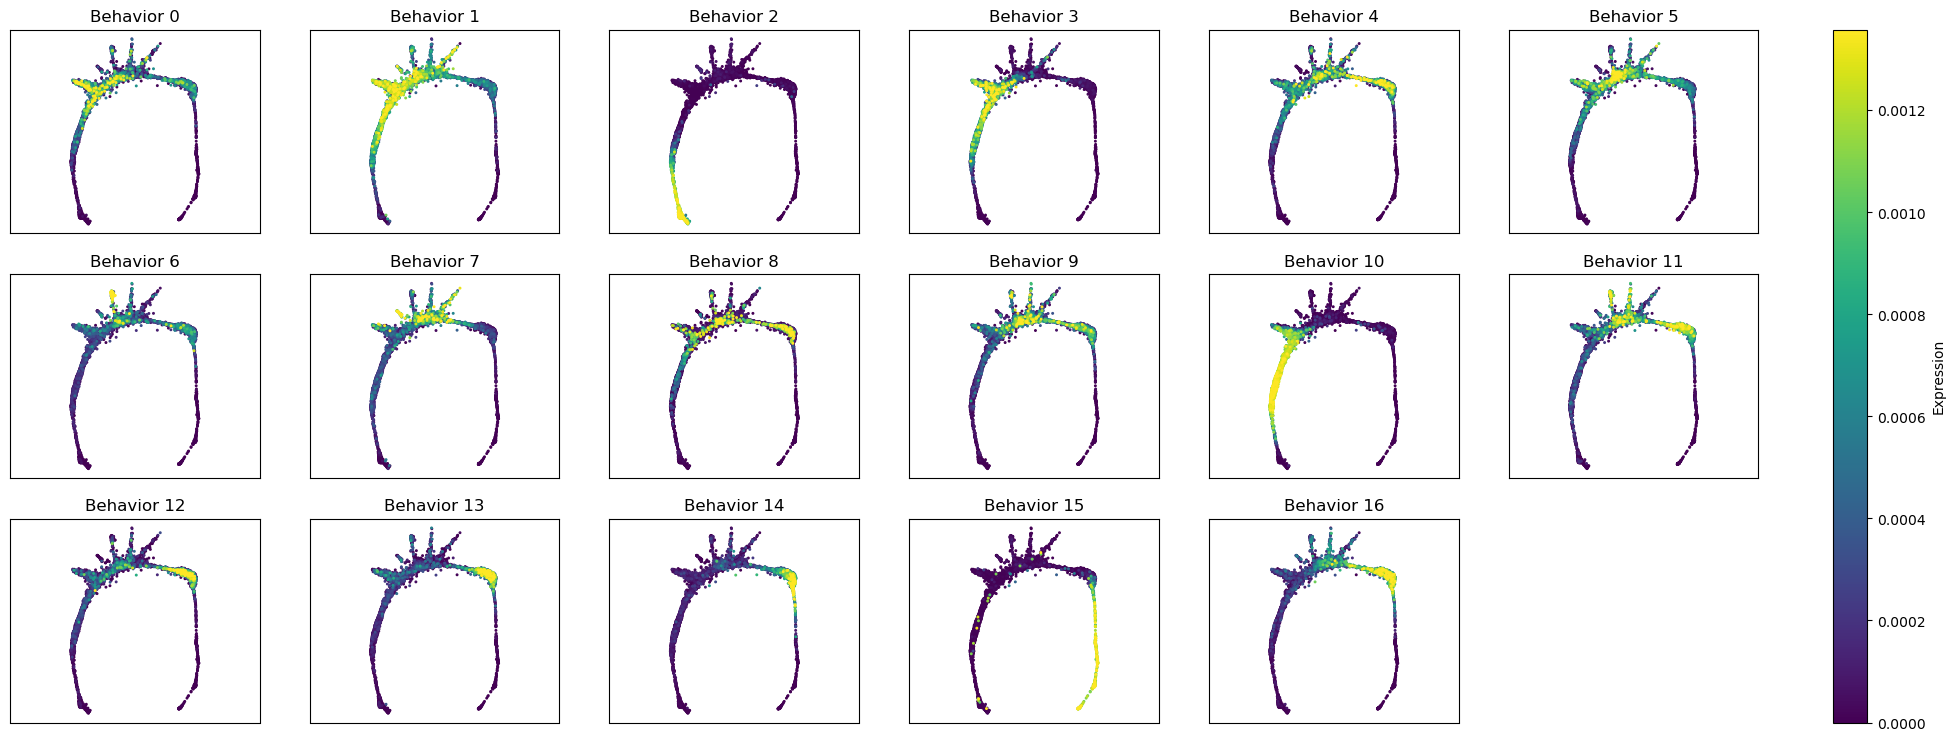

In [11]:
Tusi_scaled_17_behaviors = plotMultipleTusiBehaviors(behaviorExpr_scaled_17,tusi_orig_coord, 6, 3, 99)

#### Save figure as a PDF

In [12]:
Tusi_scaled_17_behaviors.savefig("Tusi_scaled_17_behaviors.pdf", format="pdf", bbox_inches = "tight")

#### Plot a single behavior at a time

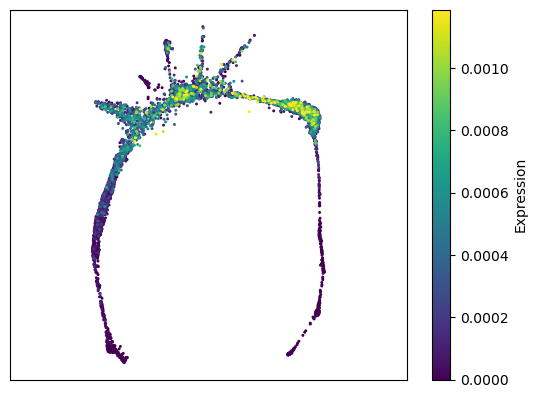

In [13]:
Tusi_single_behavior_scaled_17 = plotTusiBehavior(behaviorExpr_scaled_17[:,4], tusi_orig_coord, None, 99)